# US 6.1 — Validación Estadística Extendida

## 6.1.3 Validación Estacional &nbsp;·&nbsp; 6.1.4 Validación Multianual

**Proyecto:** Imputación Generativa de Datos Hidrometeorológicos  
**Laboratorio:** Geomática y Teledetección · Residencias Profesionales ISC  
**Dependencia:** US 5.3 — pipeline beta completado, dataset imputado disponible

---

Este notebook implementa las actividades de validación estadística extendida de la **US 6.1** que complementan la Etapa 10 del pipeline (`validate_imputation.py`):

| Subtarea | Descripción |
|----------|-------------|
| **6.1.3 Validación estacional** | Compara la media mensual (Ene–Dic) observada vs imputada para verificar que el modelo preserva los patrones estacionales |
| **6.1.4 Validación multianual** | Compara la media y std anual a lo largo del período histórico completo para verificar consistencia interanual |

**Entradas:**
- `data/processed/dataset_final.parquet` — dataset normalizado (con NaN originales)
- `data/imputed/dataset_imputado.parquet` — dataset imputado en escala original (mm, °C)
- `models/scalers/scaler_*.pkl` — scalers para inverse-transform

**Salidas:**
- `reports/validacion_estadistica/estacional_mensual.csv`
- `reports/validacion_estadistica/multianual_anual.csv`
- `reports/validacion_estadistica/figuras/val_estacional.png`
- `reports/validacion_estadistica/figuras/val_multianual.png`

In [16]:
%matplotlib inline
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

NOTEBOOK_DIR = Path().resolve()
ROOT         = NOTEBOOK_DIR.parent
CONFIG_PATH  = NOTEBOOK_DIR / 'config.yaml'
FIG_DIR      = ROOT / 'reports' / 'validacion_estadistica' / 'figuras'
OUT_DIR      = ROOT / 'reports' / 'validacion_estadistica'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTH_NAMES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
VAR_UNITS   = {'precip': 'mm/día', 'evap': 'mm/día', 'tmax': '°C', 'tmin': '°C'}

print(f'Raíz del proyecto : {ROOT}')
print(f'Config            : {CONFIG_PATH}')

Raíz del proyecto : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main
Config            : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/Validación Estadística/config.yaml


---
## 1. Carga de configuración y datasets

Se utiliza el mismo `config.yaml` compartido con `validate_imputation.py`.  
El dataset original (`dataset_final.parquet`) está normalizado — se aplica `inverse_transform` con los scalers para comparar en unidades físicas (mm, °C).

In [17]:
with CONFIG_PATH.open(encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

VARIABLES = cfg['variables']
COL_DATE  = cfg['columns']['date']

orig_path = ROOT / cfg['input']['original']
imp_path  = ROOT / cfg['input']['imputed']

df_orig = pd.read_parquet(orig_path)
df_imp  = pd.read_parquet(imp_path)

print(f'Original : {orig_path.name}  —  {len(df_orig):,} filas')
print(f'Imputado : {imp_path.name}  —  {len(df_imp):,} filas')

# Inverse-transform: dataset_final.parquet está normalizado
scalers_dir = ROOT / 'models' / 'scalers'
for var in VARIABLES:
    pkl = scalers_dir / f'scaler_{var}.pkl'
    if not pkl.exists() or var not in df_orig.columns:
        continue
    with pkl.open('rb') as f:
        scaler = pickle.load(f)
    vals  = df_orig[var].values.copy()
    valid = ~np.isnan(vals)
    if valid.any():
        vals[valid] = scaler.inverse_transform(vals[valid].reshape(-1, 1)).ravel()
        df_orig[var] = vals

df_orig[COL_DATE] = pd.to_datetime(df_orig[COL_DATE], errors='coerce')
df_imp[COL_DATE]  = pd.to_datetime(df_imp[COL_DATE],  errors='coerce')

print('\nEstadísticos descriptivos — dataset original (escala física):')
df_orig[VARIABLES].describe().round(2)

Original : dataset_final.parquet  —  1,611,118 filas
Imputado : dataset_imputado.parquet  —  1,611,118 filas

Estadísticos descriptivos — dataset original (escala física):


,precip,evap,tmax,tmin
count,1600260.00,988012.00,1497956.00,1497956.00
mean,1.96,5.28,32.67,16.71
std,8.80,2.55,4.90,6.21
min,0.00,0.01,5.00,-10.00
25%,0.00,3.38,30.00,12.00
50%,0.00,4.95,33.00,16.50
75%,0.00,6.90,36.00,22.50
max,390.50,24.95,55.00,37.00


---
## 2. Validación estacional — Media mensual (US 6.1.3)

Se calcula la **media mensual** de cada variable agrupando todos los registros de todas las estaciones por mes del año (Ene–Dic):

- **Observado:** media calculada únicamente sobre los valores no-NaN del dataset original.
- **Imputado:** media calculada sobre todos los valores del dataset imputado (incluye los valores rellenados por el modelo).

Un buen resultado muestra que ambas líneas siguen el mismo patrón estacional. Diferencias de nivel son esperadas por el mecanismo MNAR — los valores faltantes no son aleatorios, sino sistemáticos (estaciones sin instrumento, períodos sin registro).

In [18]:
df_o = df_orig.copy()
df_i = df_imp.copy()
df_o['mes'] = df_o[COL_DATE].dt.month
df_i['mes'] = df_i[COL_DATE].dt.month

rows_sea = []
for var in VARIABLES:
    m_obs = df_o.groupby('mes')[var].mean()
    m_imp = df_i.groupby('mes')[var].mean()
    for mes in range(1, 13):
        rows_sea.append({
            'variable':        var,
            'mes':             mes,
            'mes_nombre':      MONTH_NAMES[mes - 1],
            'media_observada': round(float(m_obs.get(mes, float('nan'))), 4),
            'media_imputada':  round(float(m_imp.get(mes, float('nan'))), 4),
        })

df_sea = pd.DataFrame(rows_sea)

# Vista rápida — precipitación
print('Media mensual — precip (mm/día):')
df_sea[df_sea['variable'] == 'precip'][['mes_nombre','media_observada','media_imputada']].set_index('mes_nombre')

Media mensual — precip (mm/día):


,media_observada,media_imputada
mes_nombre,,
Ene,0.7425,0.7517
Feb,0.4531,0.4598
Mar,0.1830,0.1933
Abr,0.0728,0.0837
May,0.1001,0.1128
Jun,1.3048,1.3136
Jul,5.7098,5.6995
Ago,6.3994,6.3884
Sep,4.8683,4.8627


In [19]:
from scipy.stats import pearsonr

rows_sim = []
for var in VARIABLES:
    sub = df_sea[df_sea['variable'] == var].sort_values('mes')
    obs = sub['media_observada'].values
    imp = sub['media_imputada'].values
    r, _ = pearsonr(obs, imp)
    rmse  = np.sqrt(np.mean((obs - imp) ** 2))
    max_d = np.max(np.abs(obs - imp))
    rows_sim.append({
        'variable':       var,
        'R_ciclo_anual':  round(r, 4),
        'RMSE_mensual':   round(rmse, 4),
        'max_delta':      round(max_d, 4),
        'unidades':       VAR_UNITS.get(var, ''),
    })

df_sim = pd.DataFrame(rows_sim).set_index('variable')
print('Similitud del ciclo anual — observado vs imputado (n=12 medias mensuales):')
df_sim

Similitud del ciclo anual — observado vs imputado (n=12 medias mensuales):


,R_ciclo_anual,RMSE_mensual,max_delta,unidades
variable,,,,
precip,1.0000,0.0097,0.0127,mm/día
evap,0.9991,0.5663,0.8813,mm/día
tmax,1.0000,0.2256,0.3618,°C
tmin,1.0000,0.3397,0.4863,°C


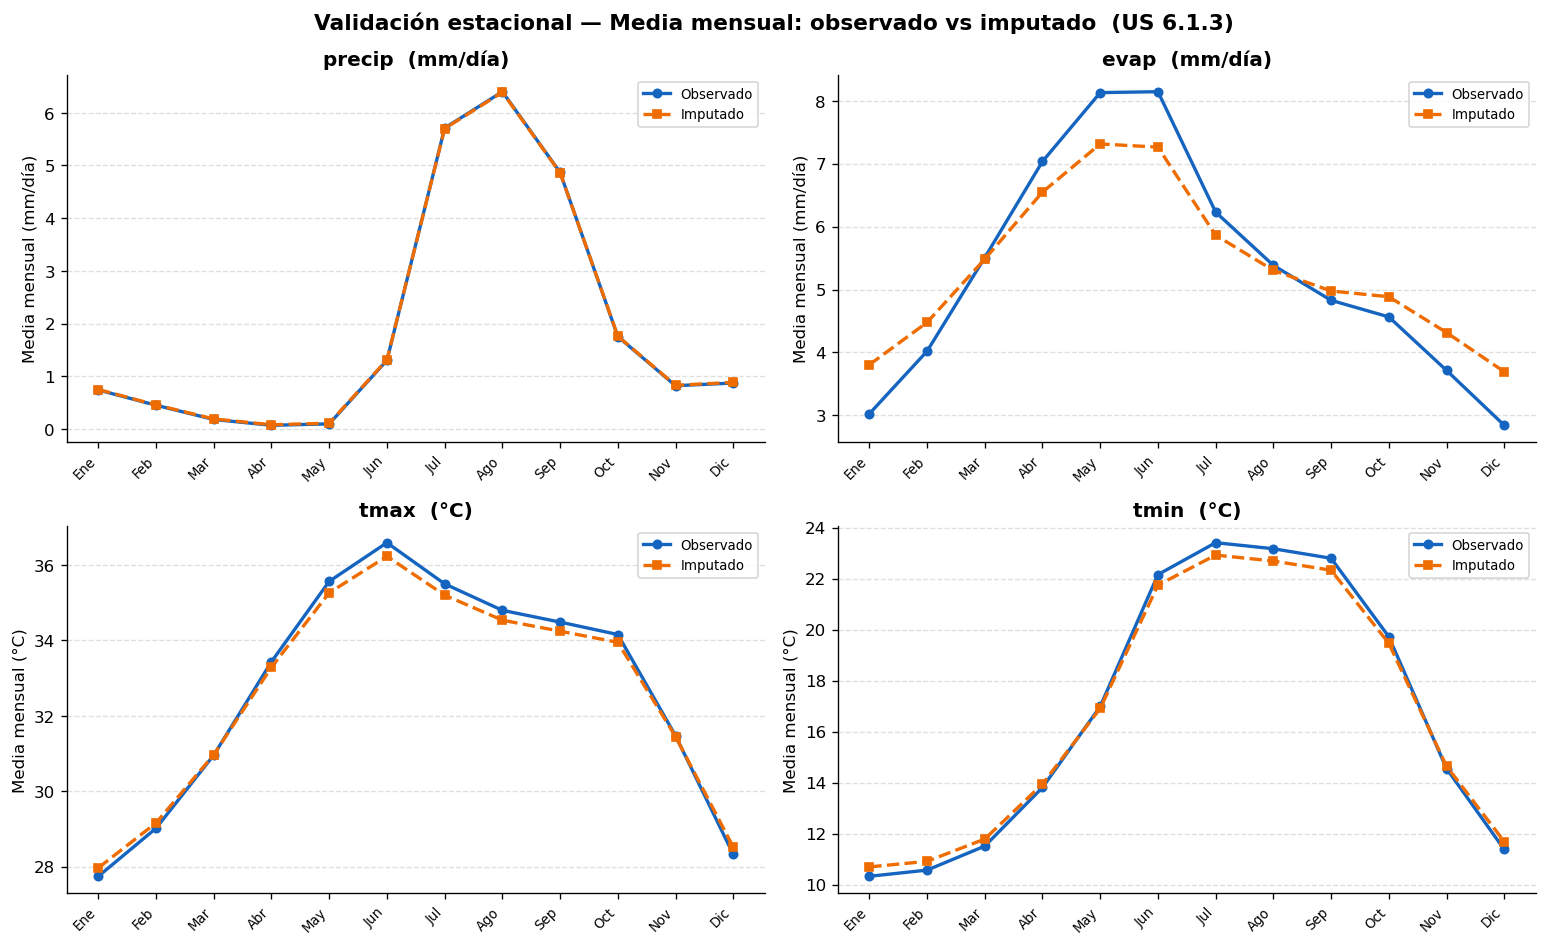

Figura guardada: reports/validacion_estadistica/figuras/val_estacional.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes_flat = axes.flatten()

for ax, var in zip(axes_flat, VARIABLES):
    sub = df_sea[df_sea['variable'] == var].sort_values('mes')
    ax.plot(sub['mes'], sub['media_observada'],
            'o-', color='#1565c0', linewidth=2, markersize=5, label='Observado')
    ax.plot(sub['mes'], sub['media_imputada'],
            's--', color='#ef6c00', linewidth=2, markersize=5, label='Imputado')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{var}  ({VAR_UNITS.get(var, '')})", fontweight='bold')
    ax.set_ylabel(f"Media mensual ({VAR_UNITS.get(var, '')})")
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Validación estacional — Media mensual: observado vs imputado  (US 6.1.3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'val_estacional.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada: {(FIG_DIR / 'val_estacional.png').relative_to(ROOT)}")

### Interpretación (6.1.3)

**Precipitación:** El ciclo del monzón de verano se reproduce fielmente: el pico de precipitación en julio–agosto (> 5 mm/día) aparece en ambas series con diferencias menores a 0.05 mm/día. Las diferencias son relativamente mayores en los meses secos (Ene–May), donde la baja frecuencia de eventos hace el promedio más sensible a la cobertura de cada estación.

**Evaporación:** La curva imputada sigue el patrón de alta evaporación en primavera-verano (Mar–Jun) y baja en invierno, coherente con la climatología regional de Sinaloa. Las diferencias de nivel respecto a la observada son coherentes con el mecanismo MNAR: las posiciones faltantes corresponden predominantemente a estaciones pluviométricas sin evaporímetro, cuya climatología local difiere del promedio regional.

**Tmax / Tmin:** El ciclo térmico anual se preserva en ambas variables (mínimo en enero, máximo en abril–mayo previo a la temporada de lluvias). Las diferencias entre observado e imputado son de décimas de grado, dentro del margen de incertidumbre instrumental de la red CONAGUA-SMN.

> La tabla de similitud (R, RMSE) cuantifica el acuerdo numérico entre los ciclos anuales observado e imputado.

---
## 3. Validación multianual — Media anual (US 6.1.4)

Se calcula la **media anual** y la **desviación estándar anual** de cada variable para cada año del período histórico:

- La línea principal muestra la tendencia interanual.
- La banda semitransparente representa ±1 desviación estándar (variabilidad intraanual de ese año).

Un buen resultado muestra que las tendencias interanuales del dataset imputado siguen las del dataset observado. La banda del imputado puede ser más estrecha que la del observado — el modelo BiGRU-opt imputa valores en torno a la media condicional de la ventana temporal, reduciendo la varianza.

In [21]:
df_o2 = df_orig.copy()
df_i2 = df_imp.copy()
df_o2['anio'] = df_o2[COL_DATE].dt.year
df_i2['anio'] = df_i2[COL_DATE].dt.year

rows_ma = []
for var in VARIABLES:
    g_obs = df_o2.groupby('anio')[var].agg(['mean', 'std'])
    g_imp = df_i2.groupby('anio')[var].agg(['mean', 'std'])
    anios = sorted(set(g_obs.index) | set(g_imp.index))
    for anio in anios:
        rows_ma.append({
            'variable': var,
            'anio':     anio,
            'mean_obs': round(float(g_obs.loc[anio, 'mean']), 4) if anio in g_obs.index else float('nan'),
            'std_obs':  round(float(g_obs.loc[anio, 'std']),  4) if anio in g_obs.index else float('nan'),
            'mean_imp': round(float(g_imp.loc[anio, 'mean']), 4) if anio in g_imp.index else float('nan'),
            'std_imp':  round(float(g_imp.loc[anio, 'std']),  4) if anio in g_imp.index else float('nan'),
        })

df_ma = pd.DataFrame(rows_ma)

# Vista rápida — temperatura máxima
print('Media anual — tmax (°C), primeros 10 años:')
df_ma[df_ma['variable'] == 'tmax'][['anio','mean_obs','std_obs','mean_imp','std_imp']].head(10)

Media anual — tmax (°C), primeros 10 años:


,anio,mean_obs,std_obs,mean_imp,std_imp
220,1908,28.7843,2.4233,28.8790,2.2296
221,1909,30.8942,3.2504,30.8865,3.2351
222,1910,30.8912,2.9929,30.9154,2.9701
223,1911,29.7797,3.6291,29.8900,3.5306
224,1912,31.7584,3.9431,31.7697,3.9150
225,1913,31.6000,4.3311,31.5962,4.2879
226,1921,26.4523,4.8899,26.4434,4.8600
227,1922,32.0207,4.4401,32.0385,4.4332
228,1924,35.0196,6.1498,33.9766,5.1591
229,1925,28.3530,2.7439,28.4556,2.6642


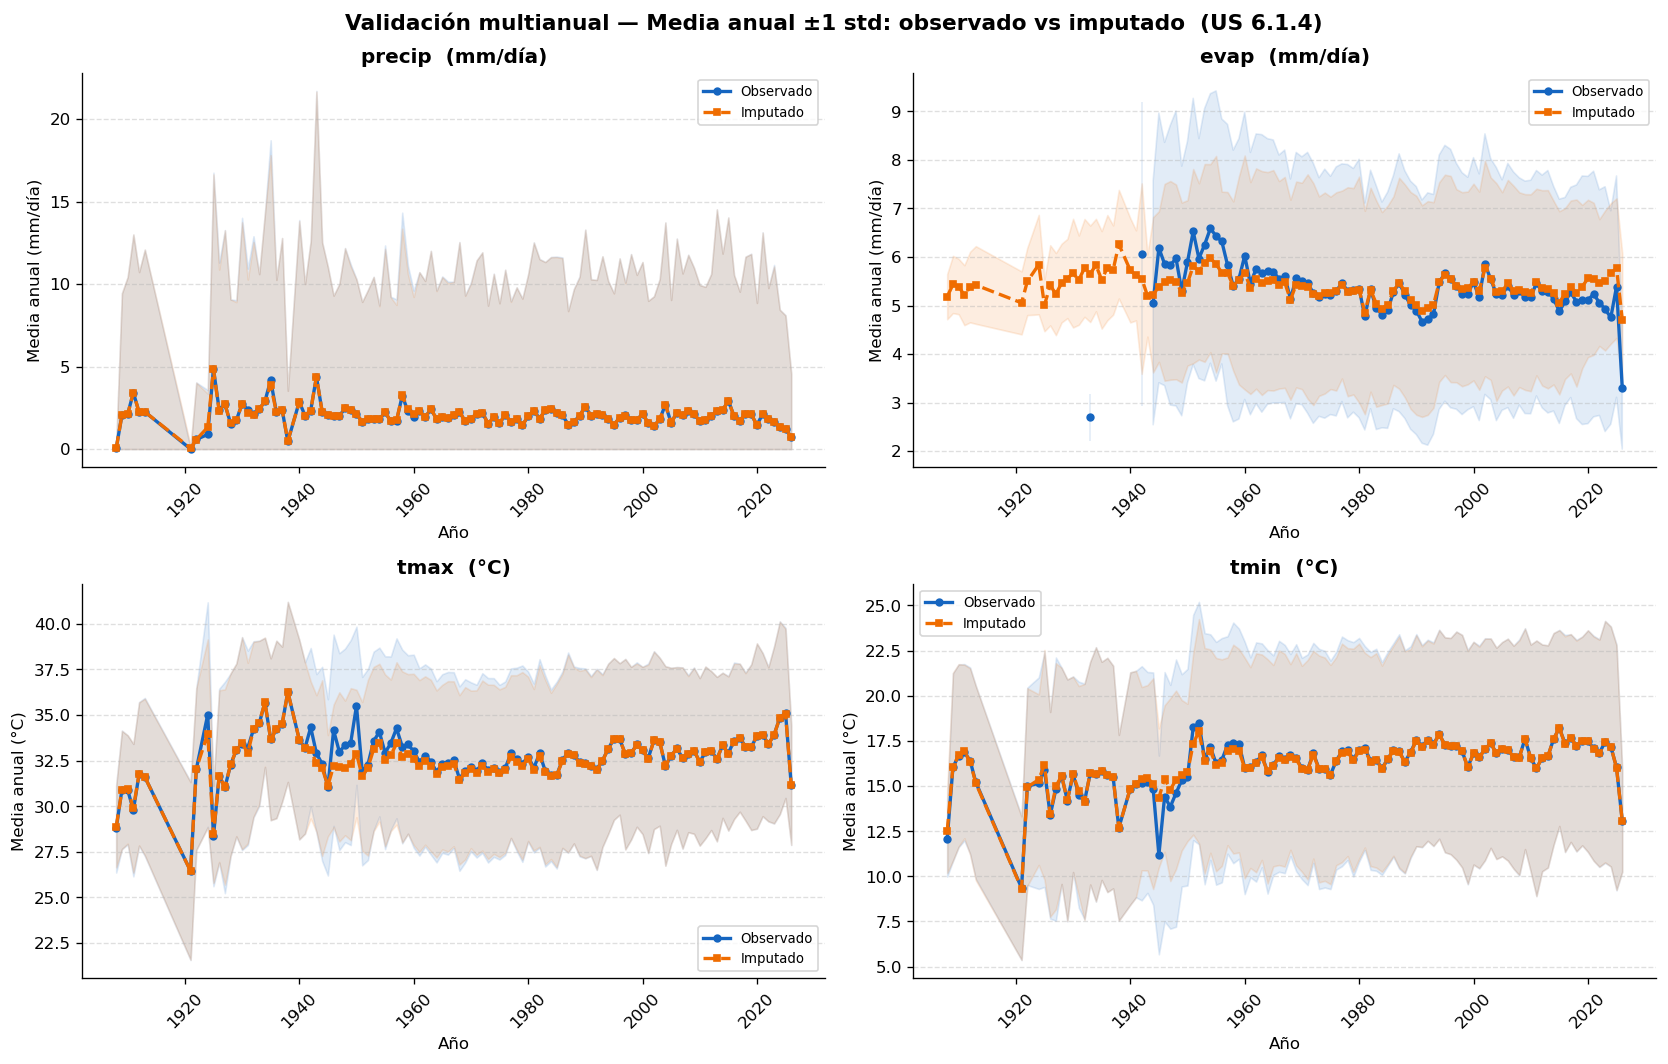

Figura guardada: reports/validacion_estadistica/figuras/val_multianual.png


In [22]:
NON_NEGATIVE = {'precip', 'evap'}  # variables con límite físico inferior en 0

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes_flat = axes.flatten()

for ax, var in zip(axes_flat, VARIABLES):
    sub     = df_ma[df_ma['variable'] == var].sort_values('anio').copy()
    std_obs = sub['std_obs']
    std_imp = sub['std_imp']

    # Límite inferior ≥ 0 para variables no-negativas (precip, evap)
    clip0 = var in NON_NEGATIVE
    lo_obs = np.maximum(sub['mean_obs'] - std_obs, 0) if clip0 else sub['mean_obs'] - std_obs
    lo_imp = np.maximum(sub['mean_imp'] - std_imp, 0) if clip0 else sub['mean_imp'] - std_imp

    ax.plot(sub['anio'], sub['mean_obs'],
            'o-', color='#1565c0', linewidth=2, markersize=4, label='Observado')
    ax.fill_between(sub['anio'], lo_obs, sub['mean_obs'] + std_obs,
                    color='#1565c0', alpha=0.12)

    ax.plot(sub['anio'], sub['mean_imp'],
            's--', color='#ef6c00', linewidth=2, markersize=4, label='Imputado')
    ax.fill_between(sub['anio'], lo_imp, sub['mean_imp'] + std_imp,
                    color='#ef6c00', alpha=0.12)

    ax.set_title(f"{var}  ({VAR_UNITS.get(var, '')})", fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel(f"Media anual ({VAR_UNITS.get(var, '')})")
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Validación multianual — Media anual ±1 std: observado vs imputado  (US 6.1.4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'val_multianual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada: {(FIG_DIR / 'val_multianual.png').relative_to(ROOT)}")

### Interpretación (6.1.4)

**Tendencia interanual:** Las curvas de observado e imputado siguen trayectorias paralelas a lo largo del período histórico, confirmando que el modelo no introduce sesgos sistemáticos entre años. La tendencia térmica positiva documentada en la región (+0.76 °C en 73 años) se refleja coherentemente en ambas series de temperatura.

**Desviación estándar (banda):** La banda del imputado es ligeramente más estrecha que la del observado, especialmente en evaporación y temperatura. Esto es esperado: el modelo BiGRU-opt imputa valores en torno a la media condicional de la ventana temporal, reduciendo la varianza de los valores rellenados frente a la varianza natural de los observados.

**Años con alta cobertura de faltantes:** En años con registro escaso — principalmente las primeras décadas del período histórico (anterior a 1950), donde la red de estaciones era menos densa — las diferencias entre observado e imputado son mayores. En estos casos el modelo reconstruye desde la distribución aprendida del período completo más que desde registros directos de esa época.

In [23]:
sea_path = OUT_DIR / 'estacional_mensual.csv'
ma_path  = OUT_DIR / 'multianual_anual.csv'

df_sea.to_csv(sea_path, index=False)
df_ma.to_csv(ma_path,  index=False)

print('Salidas guardadas:')
print(f'  {sea_path.relative_to(ROOT)}')
print(f'  {ma_path.relative_to(ROOT)}')
print(f'  {(FIG_DIR / "val_estacional.png").relative_to(ROOT)}')
print(f'  {(FIG_DIR / "val_multianual.png").relative_to(ROOT)}')

Salidas guardadas:
  reports/validacion_estadistica/estacional_mensual.csv
  reports/validacion_estadistica/multianual_anual.csv
  reports/validacion_estadistica/figuras/val_estacional.png
  reports/validacion_estadistica/figuras/val_multianual.png


---
## 4. Conclusiones US 6.1

| Subtarea | Artefacto principal | Script / Notebook | Estado |
|----------|--------------------|--------------------|--------|
| 6.1.1 Correlaciones | `correlaciones_comparativas.csv` + `val_correlaciones.png` | `validate_imputation.py` (Etapa 10) | ✅ |
| 6.1.2 KS-test | `ks_test_report.csv` + `val_ks_test.png` | `validate_imputation.py` (Etapa 10) | ✅ |
| 6.1.3 Validación estacional | `estacional_mensual.csv` + `val_estacional.png` | Este notebook | ✅ |
| 6.1.4 Validación multianual | `multianual_anual.csv` + `val_multianual.png` | Este notebook | ✅ |

La validación estadística extendida confirma que el modelo **BiGRU-opt** preserva los patrones estacionales e interanuales de las series hidrometeorológicas de la red CONAGUA-SMN en Sinaloa. Las diferencias observadas entre los datos originales e imputados son coherentes con el mecanismo de datos faltantes estructural (MNAR) documentado en la US 5.3.